关键点<br>
✅ 批次 1 的工作没有重复执行</br>
✅ 直接从失败的批次 2 继续</br>
✅ 即使进程重启，也能恢复

📚 获取数据...
⚙️  处理批次 1 (items 1-33)...
⚙️  处理批次 2 (items 34-66)...
⚙️  处理批次 3 (items 67-100)...
✅ 完成！总共处理 233 项


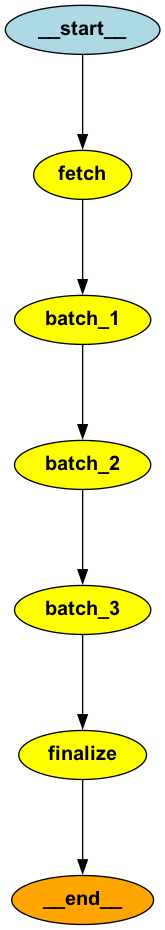

In [5]:
from typing import TypedDict, Annotated
from operator import add
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.sqlite import SqliteSaver
import time
import sqlite3

from typing import TypedDict, Annotated
from operator import add
import time

# State 定义
class PipelineState(TypedDict):
    total_items: int
    processed_items: Annotated[int, add]
    failed_items: Annotated[list, lambda old, new: old + new]
    results: Annotated[list, lambda old, new: old + new]

# 模拟步骤
def fetch_data(state: PipelineState) -> dict:
    """步骤 1: 获取数据"""
    print("📚 获取数据...")
    time.sleep(1)
    return {"total_items": 100}

def process_batch_1(state: PipelineState) -> dict:
    """步骤 2: 处理批次 1"""
    print("⚙️  处理批次 1 (items 1-33)...")
    time.sleep(2)
    return {
        "processed_items": 33,
        "results": [f"result-{i}" for i in range(1, 34)]
    }

def process_batch_2(state: PipelineState) -> dict:
    """步骤 3: 处理批次 2"""
    print("⚙️  处理批次 2 (items 34-66)...")
    time.sleep(2)

    # 模拟失败（第一次运行时）
    if state["processed_items"] == 33:
        raise Exception("💥 批次 2 处理失败！(模拟错误)")

    return {
        "processed_items": 33,
        "results": [f"result-{i}" for i in range(34, 67)]
    }

def process_batch_3(state: PipelineState) -> dict:
    """步骤 4: 处理批次 3"""
    print("⚙️  处理批次 3 (items 67-100)...")
    time.sleep(2)
    return {
        "processed_items": 34,
        "results": [f"result-{i}" for i in range(67, 101)]
    }

def finalize(state: PipelineState) -> dict:
    """步骤 5: 完成"""
    print(f"✅ 完成！总共处理 {state['processed_items']} 项")
    return {}


# 构建图
graph = StateGraph(PipelineState)
graph.add_node("fetch", fetch_data)
graph.add_node("batch_1", process_batch_1)
graph.add_node("batch_2", process_batch_2)
graph.add_node("batch_3", process_batch_3)
graph.add_node("finalize", finalize)

graph.add_edge(START, "fetch")
graph.add_edge("fetch", "batch_1")
graph.add_edge("batch_1", "batch_2")
graph.add_edge("batch_2", "batch_3")
graph.add_edge("batch_3", "finalize")
graph.add_edge("finalize", END)

# 使用 SqliteSaver
# checkpoint = SqliteSaver.from_conn_string("pipeline.db")
checkpointer = SqliteSaver(sqlite3.connect("pipeline.db", check_same_thread=False))

app = graph.compile(checkpointer=checkpointer)
# 全局唯一会话ID，同一个thread_id绑定同一份任务进度
task_config = {
    "configurable": {
        "thread_id": "3hour_batch_task_001"
    }
}
app.invoke({"total_items": 0}, task_config)

# 打印图
from IPython.display import Image, display

try:
    display(Image(app.get_graph(xray=True).draw_png()))
except Exception as e:
    rint(f"Graphviz 渲染失败: {e}")
    print("\n使用 Mermaid 文本方式显示:")
    print(workflow_app.get_graph(xray=True).draw_mermaid())